In [1]:
import scanpy as sc
import matplotlib as mpl

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:

adata = sc.read_h5ad('/Users/kylekimler/Projects/GCA/meta_datasets/integrated-objects/epithelial.h5ad')
# l_adata = sc.read_h5ad('/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/lymphoid.h5ad')

/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 35574 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


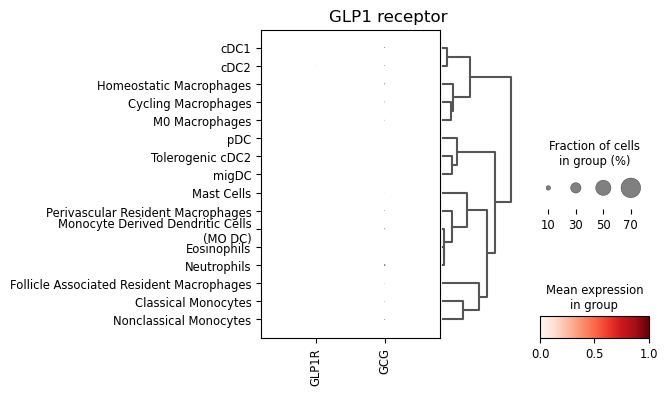

In [4]:
# adata2 = sc.read_h5ad('/Users/kylekimler/Projects/GCA/meta_datasets/integrated-objects/myeloid.h5ad')

# type_col = "hgca_celltype_v1"
# sym_col = 'gene_symbol'

# sc.pl.dotplot(
#     adata2,
#     var_names=['GLP1R','GCG'],
#     groupby=type_col,
#     gene_symbols=sym_col,
#     standard_scale="var",
#     dot_max=0.7,
#     dendrogram=True,
#     figsize=(5, 4),
#     show=True,
#     title = 'GLP1 receptor'
# )

In [3]:
for celltype in adata.obs['tissue_level_1'].unique():
    print(celltype)

colon
ileum
accessory
duodenum
jejunum


## Dotplots for rare cell types

In [4]:
adata.var

,gene_id,gene_symbol,mt,ribo,hb,feature_is_filtered
ENSG00000000003,ENSG00000000003,TSPAN6,False,False,False,False
ENSG00000000005,ENSG00000000005,TNMD,False,False,False,False
ENSG00000000419,ENSG00000000419,DPM1,False,False,False,False
ENSG00000000457,ENSG00000000457,SCYL3,False,False,False,False
ENSG00000000460,ENSG00000000460,C1orf112,False,False,False,False
...,...,...,...,...,...,...
ENSG00000288380,ENSG00000288380,CRIPAK,False,False,False,False
ENSG00000288398,ENSG00000288398,AL109627.1,False,False,False,False
ENSG00000288436,ENSG00000288436,AC024558.2,False,False,False,False
ENSG00000288459,ENSG00000288459,AL512357.2,False,False,False,False


In [ ]:
type_col = "hgca_celltype_v1"

sprue_epithelial_markers = [
    "IL15",
    "IL15RA",
    "CXCL10",
    "CXCL11",
]

cholera_epithelial_markers = [
    "CFTR",
    "ADCY6",
    "KCNQ1",
    "KCNE3",
    "GNAS",
    "PRKACA",
]

dysentery_epithelial_markers = [
    "CXCL8",
    "TLR4",
    "NOD1",
    "NOD2",
    "MUC2",
]

# rotavirus_epithelial_markers = [
#     "TLR3",
#     "DDX58",
#     "IFIH1",
#     "MAVS",
#     "STAT1",
#     "ISG15",
#     "MX1",
#     "OAS1",
#     "IFIT1",
#     "IFNL1",
#     "IFNL2",
#     "IFNL3",
# ]

rotavirus_epithelial_markers = [
    #"CD79A","IFNA1","IL22",
    "RSAD2","EIF4E","EIF4A2","EIF4G1","MTOR","ITPR3","ITPR1","PIK3CD","PIK3CA","PIK3CB","PIK3CG",
    #"CD4","TLR3","IRF7","CD8A","IFNG","PRF1","PRSS57",
    "TRIM29","AKT1","PPARG","EIF2AK2"# opentargets
]

norovirus_epithelial_markers = [
    "FUT2",
    "FUT3",
    "ABO",
    "TLR3",
    "STAT1",
    "OAS1",
    "IFIT1",
    "MX1",
]

other_daly_epithelial_markers = {
    "ETEC_secretory": [
        "GUCY2C",
        "GUCA2A",
        "GUCA2B",
        "SLC26A3",
        "SLC9A3",
    ],
    "Cryptosporidium_infection_response": [
        "STAT1",
        "ISG15",
        "MX1",
        "OAS1",
        "IFIT1",
    ],
    "C_difficile_inflammatory_diarrhea": [
        "SLC26A3",
    ],
}

marker_panels = {
    "Sprue": sprue_epithelial_markers,
    "Cholera": cholera_epithelial_markers,
    "Dysentery": dysentery_epithelial_markers,
    "Rotavirus": rotavirus_epithelial_markers,
    "Norovirus": norovirus_epithelial_markers,
    "Ecoli": other_daly_epithelial_markers['ETEC_secretory'],
}


sym_col = "gene_symbol"
sym = adata.var[sym_col].astype(str)

marker_panels = {k: [g for g in v if (sym == g).any()] for k, v in marker_panels.items()}
marker_panels = {k: v for k, v in marker_panels.items() if len(v) > 0}

mpl.rcdefaults()
mpl.rcParams["figure.figsize"] = (9, 4)

if len(marker_panels) == 0:
    raise ValueError("None of the marker genes were found in adata.var_names")

# Make dotplot with explicit figsize to avoid the gridspec error


/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 35574 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


categories: BEST4 Colonocytes, BEST4 Enterocytes, Brunners Gland Cells, etc.
var_group_labels: Sprue, Cholera, Dysentery, etc.


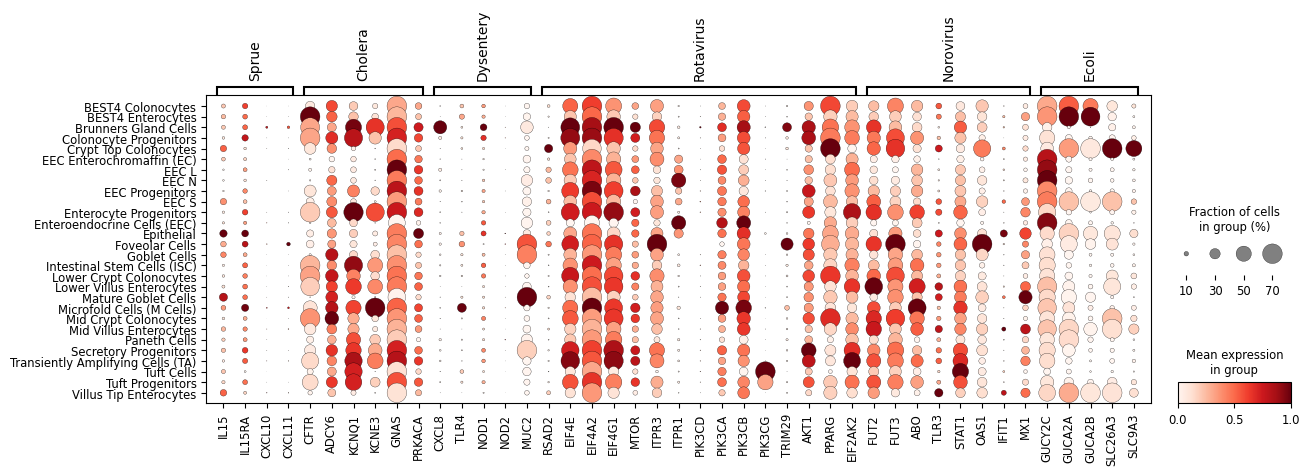

In [4]:
sc.pl.dotplot(
    adata[~adata.obs["hgca_celltype_v1"].isin(["doublet", "lowQ", "Plasma Cells", "Monocytes"])].copy(),
    var_names=marker_panels,
    groupby=type_col,
    gene_symbols=sym_col,
    standard_scale="var",
    dot_max=0.7,
#     dendrogram=True,
    figsize=(14, 4),
    show=True,
)

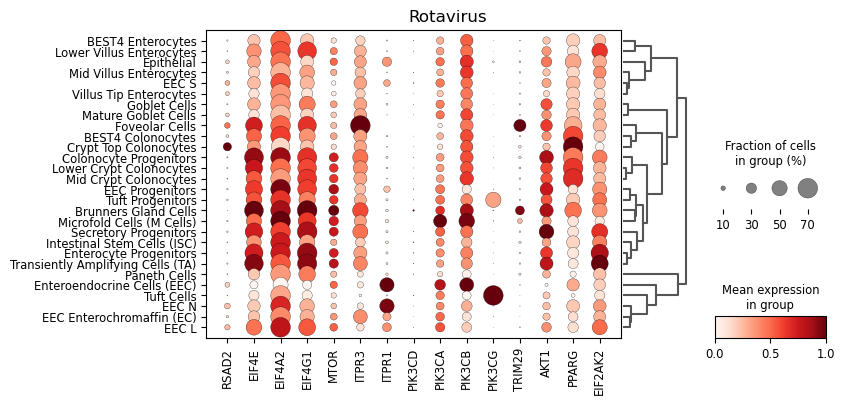

In [12]:
sc.pl.dotplot(
    adata[~adata.obs["hgca_celltype_v1"].isin(["doublet", "lowQ", "Plasma Cells", "Monocytes"])].copy(),
    var_names=marker_panels['Rotavirus'],
    groupby=type_col,
    gene_symbols=sym_col,
    standard_scale="var",
    dot_max=0.7,
    dendrogram=True,
    figsize=(8, 4),
    show=True,
    title = 'Rotavirus'
)

In [4]:
sc.pl.dotplot(
    adata[~adata.obs["hgca_celltype_v1"].isin(["doublet", "lowQ", "Plasma Cells", "Monocytes"])].copy(),
    var_names=marker_panels['Ecoli'],
    groupby=type_col,
    gene_symbols=sym_col,
    standard_scale="var",
    dot_max=0.7,
    dendrogram=True,
    figsize=(8, 4),
    show=True,
    title = 'Ecoli'
)

/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 35574 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)

KeyboardInterrupt

Exception ignored in: <function WeakSet.__init__.<locals>._remove at 0x30c40c9a0>
Traceback (most recent call last):
  File "/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/_weakrefset.py", line 39, in _remove
    def _remove(item, selfref=ref(self)):

KeyboardInterrupt: 

KeyboardInterrupt



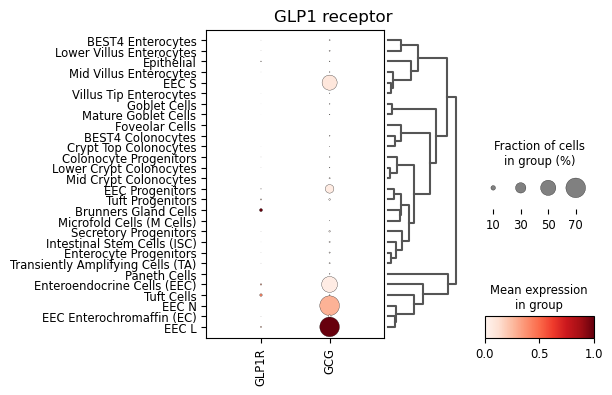

In [17]:
sc.pl.dotplot(
    adata[~adata.obs["hgca_celltype_v1"].isin(["doublet", "lowQ", "Plasma Cells", "Monocytes"])].copy(),
    var_names=['GLP1R','GCG'],
    groupby=type_col,
    gene_symbols=sym_col,
    standard_scale="var",
    dot_max=0.7,
    dendrogram=True,
    figsize=(5, 4),
    show=True,
    title = 'GLP1 receptor'
)

## celltype action in diarrhea processes

In [36]:
def style_axes_box(ax, linewidth=0.6):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(linewidth)

def expand_marker_panels(marker_panels):
    out = {}
    for k, v in marker_panels.items():
        if isinstance(v, dict):
            for kk, vv in v.items():
                out[f"{k}__{kk}"] = list(vv)
        else:
            out[k] = list(v)
    return out

def build_symbol_to_varname(adata, sym_col="gene_symbol"):
    sym = adata.var[sym_col].astype(str).values
    varnames = adata.var_names.astype(str).values
    m = {}
    for s, vn in zip(sym, varnames):
        if s and s != "nan" and s not in m:
            m[s] = vn
    return m

def map_panels_to_varnames(marker_panels, sym_to_vn):
    mapped = {}
    for k, genes in marker_panels.items():
        vn = [sym_to_vn[g] for g in genes if g in sym_to_vn]
        vn = list(dict.fromkeys(vn))
        if len(vn) > 0:
            mapped[k] = vn
    return mapped

def add_panel_scores(adata, panels_varnames, prefix="ds_", use_raw=None):
    score_cols = {}
    for name, vn_list in panels_varnames.items():
        col = f"{prefix}{name}"
        sc.tl.score_genes(adata, gene_list=vn_list, score_name=col, use_raw=use_raw)
        score_cols[name] = col
    return score_cols

def make_phase_space_summary(
    adata,
    segment_col="segment",
    type_col="hgca_celltype_v1",
    score_x_col=None,
    score_y_col=None,
):
    df = adata.obs[[segment_col, type_col, score_x_col, score_y_col]].copy()
    df = df.dropna(subset=[segment_col, type_col, score_x_col, score_y_col])
    g = df.groupby([segment_col, type_col], observed=True)
    out = g.agg(
        n_cells=(score_x_col, "size"),
        x_mean=(score_x_col, "mean"),
        y_mean=(score_y_col, "mean"),
    ).reset_index()
    return out

def plot_phase_space_by_segment(
    summary_df,
    segments_order,
    x_col="x_mean",
    y_col="y_mean",
    size_col="n_cells",
    segment_col="segment",
    type_col="hgca_celltype_v1",
    segment_colors=None,
    n_cols=3,
    figsize_per=(5.0, 4.5),
    title_prefix="",
    xlab="",
    ylab="",
    label_mode="top_n",
    label_top_n=8,
    label_min_cells=0,
    label_fontsize=7,
    label_dx_frac=0.008,
    label_dy_frac=0.008,
):
    segments_present = [s for s in segments_order if s in summary_df[segment_col].unique()]
    if len(segments_present) == 0:
        raise ValueError("No segments present after filtering")

    subset = summary_df[summary_df[segment_col].isin(segments_present)].copy()
    x_all = subset[x_col].values
    y_all = subset[y_col].values
    x_pad = 0.1 * (np.nanmax(x_all) - np.nanmin(x_all) if np.isfinite(x_all).any() else 1.0)
    y_pad = 0.1 * (np.nanmax(y_all) - np.nanmin(y_all) if np.isfinite(y_all).any() else 1.0)
    xlim = (np.nanmin(x_all) - x_pad, np.nanmax(x_all) + x_pad)
    ylim = (np.nanmin(y_all) - y_pad, np.nanmax(y_all) + y_pad)

    dx = (xlim[1] - xlim[0]) * label_dx_frac
    dy = (ylim[1] - ylim[0]) * label_dy_frac

    n = len(segments_present)
    n_cols = min(n_cols, n)
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per[0] * n_cols, figsize_per[1] * n_rows),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, seg in zip(axes, segments_present):
        sub = subset[subset[segment_col] == seg].copy()
        x = sub[x_col].values
        y = sub[y_col].values
        sz = sub[size_col].values.astype(float)
        sz_scaled = 320.0 * (sz / np.nanmax(sz)) if np.nanmax(sz) > 0 else np.full_like(sz, 40.0)

        color = "#025773"
        if segment_colors is not None:
            color = segment_colors.get(seg, color)

        ax.scatter(
            x,
            y,
            s=sz_scaled,
            alpha=0.85,
            color=color,
            edgecolor="white",
            linewidth=0.4,
        )

        ax.set_title(f"{title_prefix}{seg}", fontsize=11)
        ax.axhline(0, linewidth=0.8, color="gray", alpha=0.6)
        ax.axvline(0, linewidth=0.8, color="gray", alpha=0.6)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        style_axes_box(ax)

        to_label = sub.copy()
        if label_min_cells > 0:
            to_label = to_label[to_label[size_col] >= label_min_cells]

        if label_mode == "all":
            pass
        elif label_mode == "top_n":
            to_label = to_label.sort_values(size_col, ascending=False).head(label_top_n)
        else:
            raise ValueError("label_mode must be 'top_n' or 'all'")

        if len(to_label) > 0:
            for j, (_, r) in enumerate(to_label.iterrows()):
                lx = r[x_col]
                ly = r[y_col]
                txt = str(r[type_col])

                sgnx = 1 if (j % 2 == 0) else -1
                sgny = 1 if ((j // 2) % 2 == 0) else -1

                ax.text(
                    lx + sgnx * dx,
                    ly + sgny * dy,
                    txt,
                    fontsize=label_fontsize,
                    ha="left" if sgnx > 0 else "right",
                    va="bottom" if sgny > 0 else "top",
                )

    for ax in axes[len(segments_present):]:
        ax.axis("off")

    for i, ax in enumerate(axes[:len(segments_present)]):
        row = i // n_cols
        col = i % n_cols
        if row == n_rows - 1:
            ax.set_xlabel(xlab, fontsize=10)
        else:
            ax.set_xlabel("")
        if col == 0:
            ax.set_ylabel(ylab, fontsize=10)
        else:
            ax.set_ylabel("")

    plt.tight_layout()
    plt.show()
    
    

In [37]:

segment_col = "tissue_level_1"
type_col = "hgca_celltype_v1"
sym_col = "gene_symbol"


In [38]:
marker_panels_expanded = expand_marker_panels(marker_panels)
sym_to_vn = build_symbol_to_varname(adata, sym_col=sym_col)
panels_varnames = map_panels_to_varnames(marker_panels_expanded, sym_to_vn)
if len(panels_varnames) == 0:
    raise ValueError("None of the marker genes were found in adata.var[sym_col]")

score_cols = add_panel_scores(adata, panels_varnames, prefix="ds_", use_raw=None)

x_panel = "Norovirus_epithelial"
y_panel = "Rotavirus_epithelial"
x_col = score_cols[x_panel]
y_col = score_cols[y_panel]

adata_use = adata.copy()

summary = make_phase_space_summary(
    adata_use,
    segment_col=segment_col,
    type_col=type_col,
    score_x_col=x_col,
    score_y_col=y_col,
).rename(columns={segment_col: "tissue_level_1", type_col: "hgca_celltype_v1"})


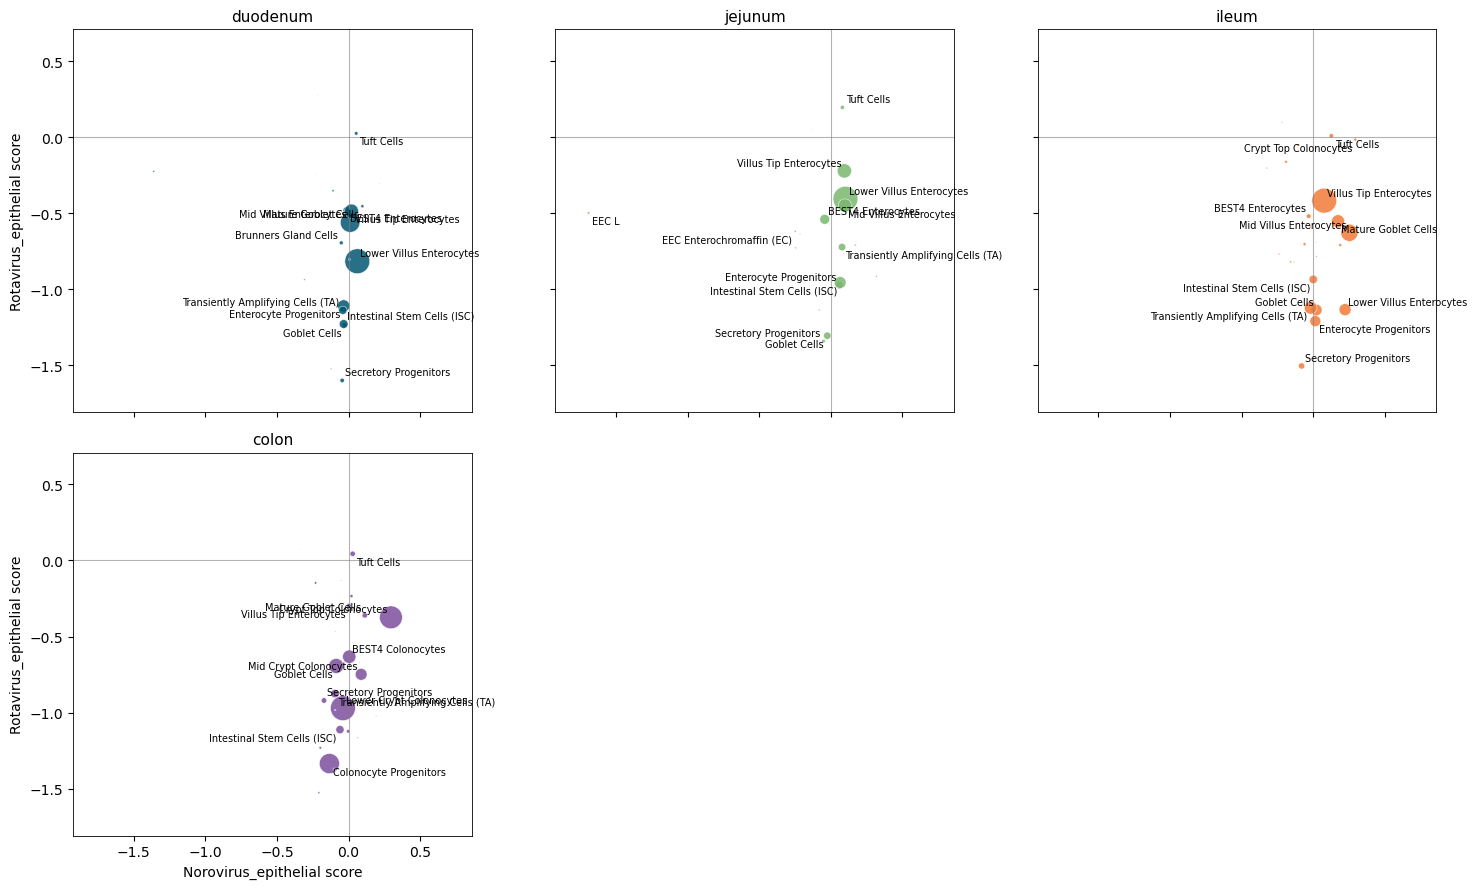

In [14]:
segments_order = ["duodenum", "jejunum", "ileum", "colon", "appendix", "unknown"]
segment_colors = {
    "duodenum": "#025773",
    "jejunum": "#7ab66f",
    "ileum": "#f27c38",
    "colon": "#7b4f9d",
    "appendix": "#f0c808",
    "unknown": "#8c8c8c",
}

plot_phase_space_by_segment(
    summary_df=summary,
    segments_order=segments_order,
    x_col="x_mean",
    y_col="y_mean",
    size_col="n_cells",
    segment_col="tissue_level_1",
    type_col="hgca_celltype_v1",
    segment_colors=segment_colors,
    n_cols=3,
    figsize_per=(5.0, 4.5),
    title_prefix="",
    xlab=f"{x_panel} score",
    ylab=f"{y_panel} score",
    label_top_n=12,
    label_min_cells=10,
    label_fontsize=7,
)


# plot_phase_space_by_segment(
#     summary_df=summary,
#     segments_order=segments_order,
#     segment_colors=segment_colors,
#     xlab=f"{x_panel} score",
#     ylab=f"{y_panel} score",
#     label_mode="top_n",

# )

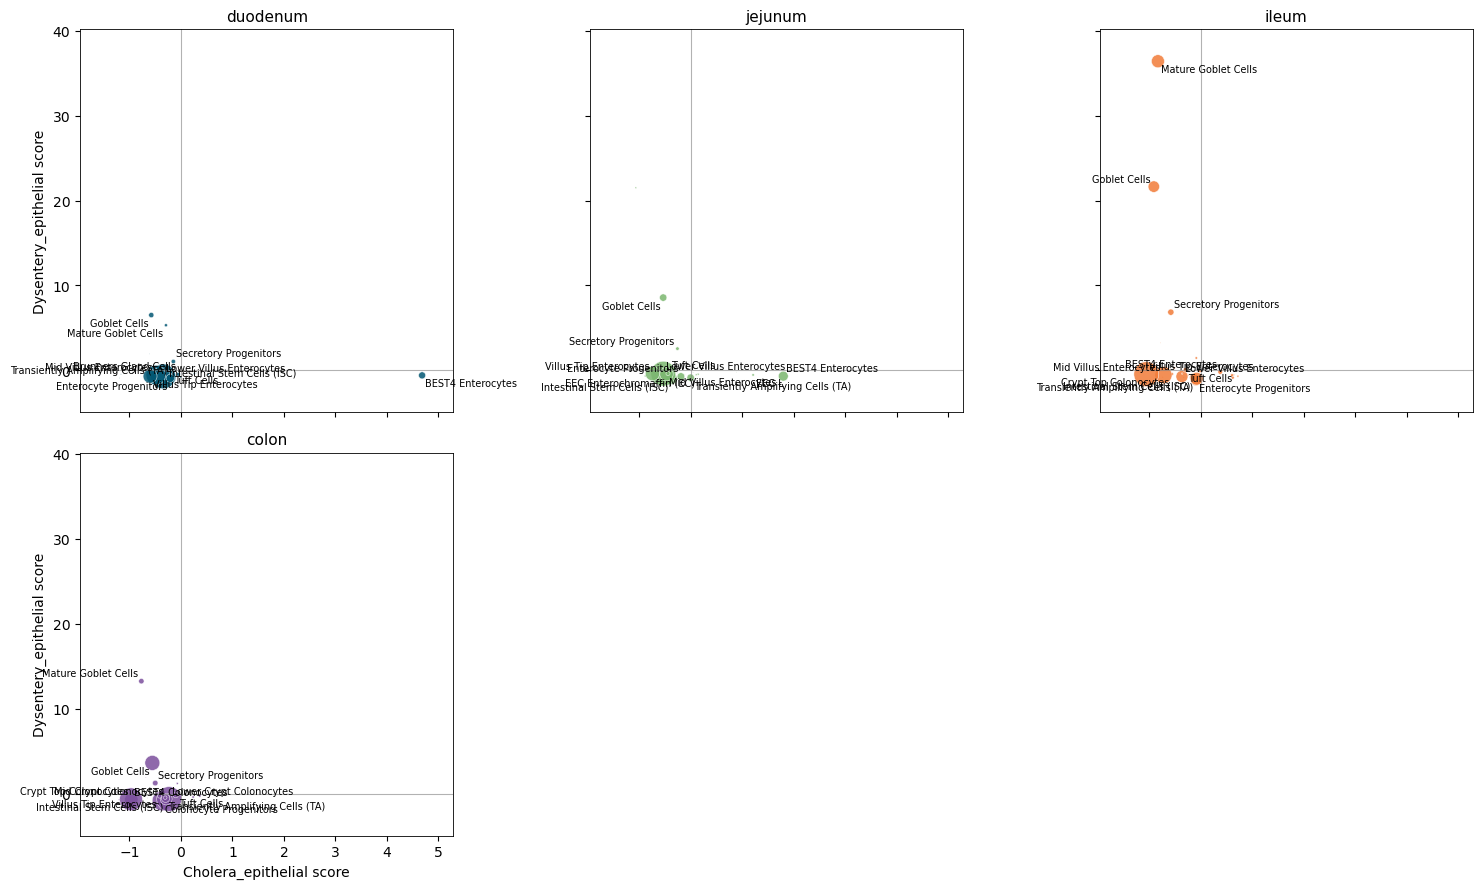

In [38]:

x_panel = "Cholera_epithelial"
y_panel = "Dysentery_epithelial"
x_col = score_cols[x_panel]
y_col = score_cols[y_panel]

adata_use = adata.copy()

summary = make_phase_space_summary(
    adata_use,
    segment_col=segment_col,
    type_col=type_col,
    score_x_col=x_col,
    score_y_col=y_col,
).rename(columns={segment_col: "tissue_level_1", type_col: "hgca_celltype_v1"})


plot_phase_space_by_segment(
    summary_df=summary,
    segments_order=segments_order,
    x_col="x_mean",
    y_col="y_mean",
    size_col="n_cells",
    segment_col="tissue_level_1",
    type_col="hgca_celltype_v1",
    segment_colors=segment_colors,
    n_cols=3,
    figsize_per=(5.0, 4.5),
    title_prefix="",
    xlab=f"{x_panel} score",
    ylab=f"{y_panel} score",
    label_top_n=12,
    label_min_cells=10,
    label_fontsize=7,
)


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from adjustText import adjust_text
    HAVE_ADJUST = True
except ImportError:
    HAVE_ADJUST = False


def style_axes_box(ax, linewidth=0.6):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(linewidth)


def minmax01(x):
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return x
    lo = np.nanmin(x)
    hi = np.nanmax(x)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.zeros_like(x, dtype=float)
    return (x - lo) / (hi - lo)


def summarize_single_score(adata, segment_col, type_col, score_col):
    df = adata.obs[[segment_col, type_col, score_col]].copy()
    df = df.dropna(subset=[segment_col, type_col, score_col])

    out = (
        df.groupby([segment_col, type_col], observed=True)
        .agg(
            n_cells=(score_col, "size"),
            score_mean=(score_col, "mean"),
            score_sd=(score_col, "std"),
        )
        .reset_index()
    )
    return out


def build_diarrhea_long_summary(
    adata,
    score_cols,
    diarrhea_panels,
    segment_col,
    type_col,
):
    dfs = []
    for panel in diarrhea_panels:
        score_col = score_cols[panel]
        sub = summarize_single_score(
            adata=adata,
            segment_col=segment_col,
            type_col=type_col,
            score_col=score_col,
        ).rename(columns={
            segment_col: "tissue_level_1",
            type_col: "hgca_celltype_v1",
        })

        sub["diarrhea_subtype"] = panel.replace("_epithelial", "")
        dfs.append(sub)

    return pd.concat(dfs, ignore_index=True)



def plot_diarrhea_subtype_facets(
    long_df,
    segments_order,
    subtype_order,
    subtype_colors,
    figsize_per=(5.0, 4.6),
    n_cols=3,
    label_top_n=12,
    label_min_cells=10,
    label_fontsize=7,
    jitter_width=0.16,
):
    segments_present = [s for s in segments_order if s in long_df["tissue_level_1"].unique()]
    n_panels = len(segments_present)
    n_rows = int(np.ceil(n_panels / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per[0] * n_cols, figsize_per[1] * n_rows),
        sharey=True,
    )
    axes = np.atleast_1d(axes).ravel()

    x_map = {k: i for i, k in enumerate(subtype_order)}

    for ax, seg in zip(axes, segments_present):
        sub = long_df.loc[long_df["tissue_level_1"] == seg].copy()

        for subtype in subtype_order:
            ss = sub.loc[sub["diarrhea_subtype"] == subtype].copy()
            if ss.empty:
                continue

            x0 = x_map[subtype]
            if len(ss) == 1:
                xvals = np.array([x0])
            else:
                offsets = np.linspace(-jitter_width, jitter_width, len(ss))
                order = np.argsort(ss["score_mean"].values)
                xvals = np.empty(len(ss))
                xvals[order] = x0 + offsets

            ax.scatter(
                xvals,
                ss["score_mean"].values,
                s=20 + 80 * minmax01(np.sqrt(ss["n_cells"].values)),
                color=subtype_colors[subtype],
                edgecolor="black",
                linewidth=0.35,
                alpha=0.9,
            )

        candidates = (
            sub.loc[sub["n_cells"] >= label_min_cells]
            .sort_values("score_mean", ascending=False)
            .groupby("hgca_celltype_v1", as_index=False)
            .head(1)
            .sort_values("score_mean", ascending=False)
            .head(label_top_n)
            .copy()
        )

        texts = []
        for _, r in candidates.iterrows():
            x0 = x_map[r["diarrhea_subtype"]]
            txt = ax.text(
                x0 + 0.03,
                r["score_mean"],
                r["hgca_celltype_v1"],
                fontsize=label_fontsize,
                ha="left",
                va="bottom",
            )
            texts.append(txt)

        if HAVE_ADJUST and len(texts) > 0:
            adjust_text(
                texts,
                ax=ax,
                arrowprops=dict(arrowstyle="-", lw=0.4, color="black"),
            )

        ax.set_title(seg)
        ax.set_xticks(range(len(subtype_order)))
        ax.set_xticklabels(subtype_order, rotation=30, ha="right")
        ax.set_ylabel("Program score")
        style_axes_box(ax)

    for ax in axes[n_panels:]:
        ax.axis("off")

    handles = [
        plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            markerfacecolor=subtype_colors[s],
            markeredgecolor="black",
            markeredgewidth=0.4,
            markersize=7,
            label=s,
        )
        for s in subtype_order
    ]

    fig.legend(
        handles=handles,
        labels=subtype_order,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
        title="Diarrhea subtype",
    )

    plt.tight_layout(rect=[0, 0, 0.88, 1])
    return fig, axes




In [45]:
diarrhea_panels = [
    "Norovirus_epithelial",
    "Rotavirus_epithelial",
    "Cholera_epithelial",
    "Dysentery_epithelial",
]

subtype_order = ["Norovirus", "Rotavirus", "Cholera", "Dysentery"]
subtype_colors = {
    "Norovirus": "#1b9e77",
    "Rotavirus": "#d95f02",
    "Cholera": "#7570b3",
    "Dysentery": "#e7298a",
}

diarrhea_long = build_diarrhea_long_summary(
    adata=adata,
    score_cols=score_cols,
    diarrhea_panels=diarrhea_panels,
    segment_col=segment_col,
    type_col=type_col,
)

fig1, axes1 = plot_diarrhea_subtype_facets(
    long_df=diarrhea_long,
    segments_order=segments_order,
    subtype_order=subtype_order,
    subtype_colors=subtype_colors,
    n_cols=3,
    label_top_n=12,
    label_min_cells=10,
    label_fontsize=7,
)
plt.show()

fig1.savefig(f"/Users/kylekimler/Projects/GCA/github_vignette_output/diarrhea_subtypes_signatures_celltypes_segments_epithelial.png", dpi=400, bbox_inches="tight")


In [41]:



def build_diarrhea_aggregate_summary(long_df):
    df = long_df.copy()

    agg = (
        df.groupby(
            ["tissue_level_1", "hgca_celltype_v1"],
            observed=True,
            as_index=False,
        )
        .agg(
            diarrhea_score_mean=("score_mean", "mean"),
            diarrhea_score_max=("score_mean", "max"),
            diarrhea_score_sd_across_subtypes=("score_mean", "std"),
            n_cells=("n_cells", "max"),
            n_subtypes_present=("diarrhea_subtype", "nunique"),
        )
    )

    agg["diarrhea_score_sd_across_subtypes"] = agg["diarrhea_score_sd_across_subtypes"].fillna(0)
    return agg

def plot_diarrhea_aggregate_facets(
    agg_df,
    segments_order,
    figsize_per=(5.2, 4.8),
    n_cols=3,
    label_top_n=12,
    label_min_cells=10,
    label_fontsize=7,
):
    segments_present = [s for s in segments_order if s in agg_df["tissue_level_1"].unique()]
    n_panels = len(segments_present)
    n_rows = int(np.ceil(n_panels / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per[0] * n_cols, figsize_per[1] * n_rows),
        sharex=True,
        sharey=False,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, seg in zip(axes, segments_present):
        sub = agg_df.loc[agg_df["tissue_level_1"] == seg].copy()
        sub = sub.sort_values("diarrhea_score_mean", ascending=False).reset_index(drop=True)
        sub["ypos"] = np.arange(len(sub))[::-1]

        ax.scatter(
            sub["diarrhea_score_mean"],
            sub["ypos"],
            s=20 + 90 * minmax01(np.sqrt(sub["n_cells"].values)),
            color="black",
            edgecolor="black",
            linewidth=0.35,
            alpha=0.85,
        )

        lab = (
            sub.loc[sub["n_cells"] >= label_min_cells]
            .sort_values("diarrhea_score_mean", ascending=False)
            .head(label_top_n)
            .copy()
        )

        texts = []
        for _, r in lab.iterrows():
            txt = ax.text(
                r["diarrhea_score_mean"],
                r["ypos"],
                "  " + r["hgca_celltype_v1"],
                fontsize=label_fontsize,
                ha="left",
                va="center",
            )
            texts.append(txt)

        if HAVE_ADJUST and len(texts) > 0:
            adjust_text(
                texts,
                ax=ax,
                arrowprops=dict(arrowstyle="-", lw=0.4, color="black"),
            )

        ax.set_title(seg)
        ax.set_xlabel("Aggregated gene program score across diarrhea subtypes")
        ax.set_yticks([])
        style_axes_box(ax)

    for ax in axes[n_panels:]:
        ax.axis("off")

    plt.tight_layout()
    return fig, axes

In [48]:
diarrhea_agg = build_diarrhea_aggregate_summary(diarrhea_long)

fig2, axes2 = plot_diarrhea_aggregate_facets(
    agg_df=diarrhea_agg,
    segments_order=segments_order,
    n_cols=3,
    label_top_n=12,
    label_min_cells=10,
    label_fontsize=7,
)
plt.show()

# fig2.savefig(f"/Users/kylekimler/Projects/GCA/github_vignette_output/diarrhea_signatures_celltypes_segments_epithelial.png", dpi=400, bbox_inches="tight")


In [28]:
adata = sc.read_h5ad('/Users/kylekimler/Projects/GCA/meta_datasets/integrated-objects/stroma.h5ad')


In [30]:
marker_panels_expanded = expand_marker_panels(marker_panels)
sym_to_vn = build_symbol_to_varname(adata, sym_col=sym_col)
panels_varnames = map_panels_to_varnames(marker_panels_expanded, sym_to_vn)
if len(panels_varnames) == 0:
    raise ValueError("None of the marker genes were found in adata.var[sym_col]")

score_cols = add_panel_scores(adata, panels_varnames, prefix="ds_", use_raw=None)

x_panel = "Norovirus_epithelial"
y_panel = "Rotavirus_epithelial"
x_col = score_cols[x_panel]
y_col = score_cols[y_panel]

adata_use = adata.copy()

summary = make_phase_space_summary(
    adata_use,
    segment_col=segment_col,
    type_col=type_col,
    score_x_col=x_col,
    score_y_col=y_col,
).rename(columns={segment_col: "tissue_level_1", type_col: "hgca_celltype_v1"})


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_95323/2860915855.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("hgca_celltype_v1", as_index=False)
/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_95323/2860915855.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("hgca_celltype_v1", as_index=False)
/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_95323/2860915855.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True 

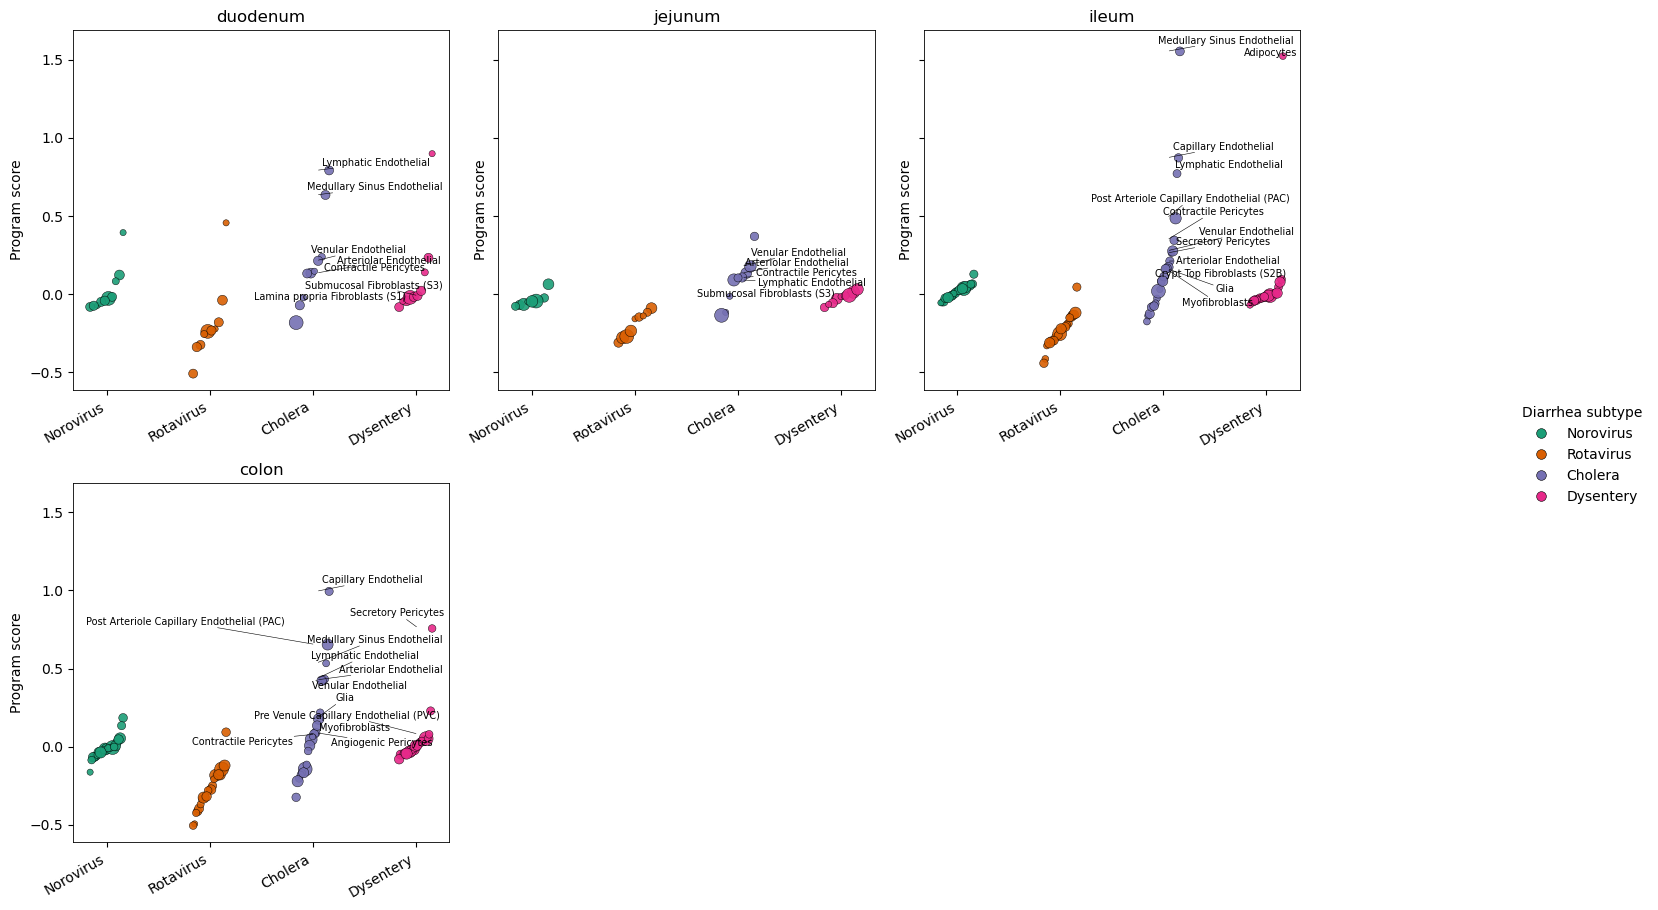

In [31]:
diarrhea_panels = [
    "Norovirus_epithelial",
    "Rotavirus_epithelial",
    "Cholera_epithelial",
    "Dysentery_epithelial",
]

subtype_order = ["Norovirus", "Rotavirus", "Cholera", "Dysentery"]
subtype_colors = {
    "Norovirus": "#1b9e77",
    "Rotavirus": "#d95f02",
    "Cholera": "#7570b3",
    "Dysentery": "#e7298a",
}

diarrhea_long = build_diarrhea_long_summary(
    adata=adata,
    score_cols=score_cols,
    diarrhea_panels=diarrhea_panels,
    segment_col=segment_col,
    type_col=type_col,
)

fig1, axes1 = plot_diarrhea_subtype_facets(
    long_df=diarrhea_long,
    segments_order=segments_order,
    subtype_order=subtype_order,
    subtype_colors=subtype_colors,
    n_cols=3,
    label_top_n=12,
    label_min_cells=10,
    label_fontsize=7,
)
plt.show()



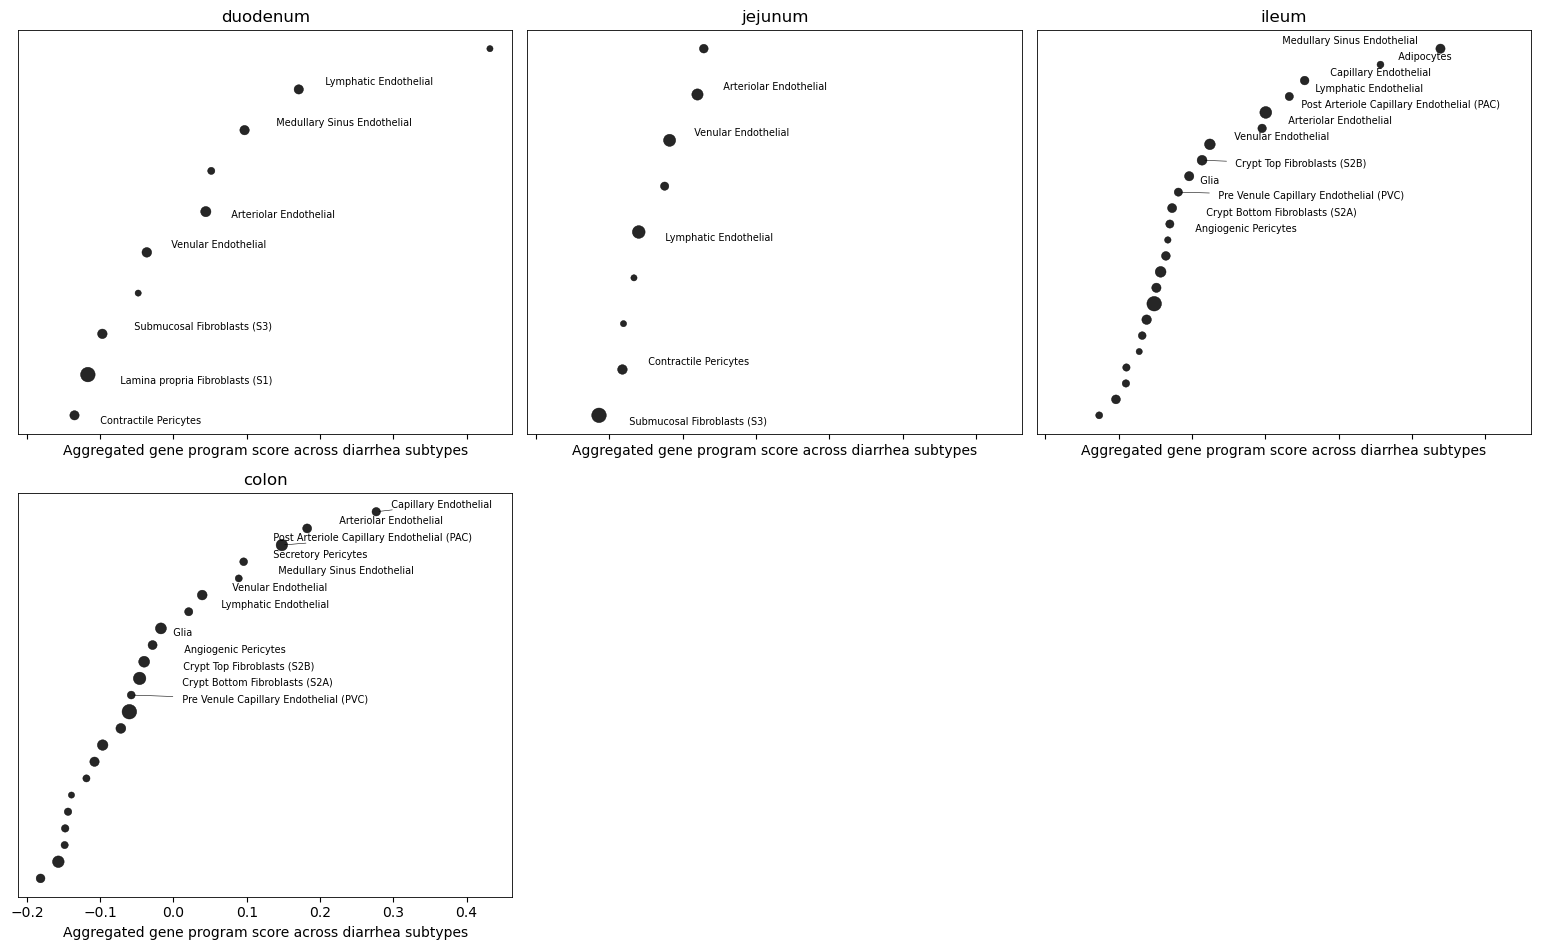

In [32]:
diarrhea_agg = build_diarrhea_aggregate_summary(diarrhea_long)

fig2, axes2 = plot_diarrhea_aggregate_facets(
    agg_df=diarrhea_agg,
    segments_order=segments_order,
    n_cols=3,
    label_top_n=12,
    label_min_cells=10,
    label_fontsize=7,
)
plt.show()




/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 35574 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


categories: BEST4 Colonocytes, BEST4 Enterocytes, Brunners Gland Cells, etc.
var_group_labels: Sprue_epithelial, Cholera_epithelial, Dysentery_epithelial, etc.


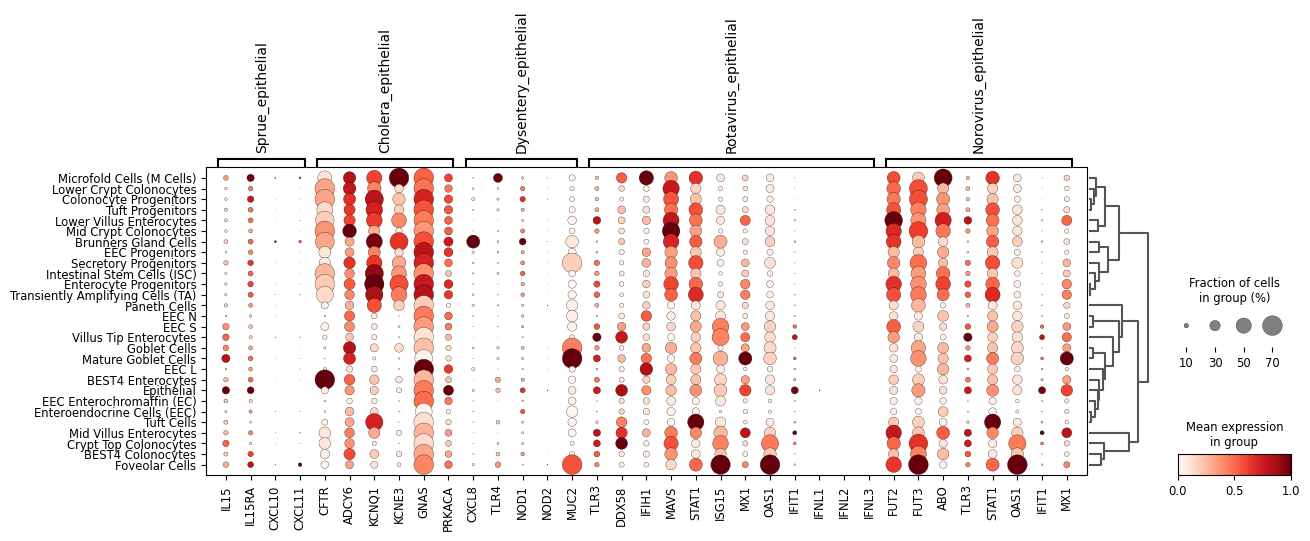

In [21]:
type_col = "hgca_celltype_v1"

sprue_epithelial_markers = [
    "IL15",
    "IL15RA",
    "CXCL10",
    "CXCL11",
]

cholera_epithelial_markers = [
    "CFTR",
    "ADCY6",
    "KCNQ1",
    "KCNE3",
    "GNAS",
    "PRKACA",
]

dysentery_epithelial_markers = [
    "CXCL8",
    "TLR4",
    "NOD1",
    "NOD2",
    "MUC2",
]

rotavirus_epithelial_markers = [
    "TLR3",
    "DDX58",
    "IFIH1",
    "MAVS",
    "STAT1",
    "ISG15",
    "MX1",
    "OAS1",
    "IFIT1",
    "IFNL1",
    "IFNL2",
    "IFNL3",
]

norovirus_epithelial_markers = [
    "FUT2",
    "FUT3",
    "ABO",
    "TLR3",
    "STAT1",
    "OAS1",
    "IFIT1",
    "MX1",
]

other_daly_epithelial_markers = {
    "ETEC_secretory": [
        "GUCY2C",
        "GUCA2A",
        "GUCA2B",
        "SLC26A3",
        "SLC9A3",
    ],
    "Cryptosporidium_infection_response": [
        "STAT1",
        "ISG15",
        "MX1",
        "OAS1",
        "IFIT1",
    ],
    "C_difficile_inflammatory_diarrhea": [
        "SLC26A3",
    ],
}

marker_panels = {
    "Sprue_epithelial": sprue_epithelial_markers,
    "Cholera_epithelial": cholera_epithelial_markers,
    "Dysentery_epithelial": dysentery_epithelial_markers,
    "Rotavirus_epithelial": rotavirus_epithelial_markers,
    "Norovirus_epithelial": norovirus_epithelial_markers,
    "Other_DALY_epithelial": other_daly_epithelial_markers,
}


sym_col = "gene_symbol"
sym = adata.var[sym_col].astype(str)

marker_panels = {k: [g for g in v if (sym == g).any()] for k, v in marker_panels.items()}
marker_panels = {k: v for k, v in marker_panels.items() if len(v) > 0}

mpl.rcdefaults()
mpl.rcParams["figure.figsize"] = (9, 4)

if len(marker_panels) == 0:
    raise ValueError("None of the marker genes were found in adata.var_names")

# Make dotplot with explicit figsize to avoid the gridspec error
sc.pl.dotplot(
    adata[~adata.obs["hgca_celltype_v1"].isin(["doublet", "lowQ", "Plasma Cells", "Monocytes"])].copy(),
    var_names=marker_panels,
    groupby=type_col,
    gene_symbols=sym_col,
    standard_scale="var",
    dot_max=0.7,
    figsize=(14, 4),
    show=True,
    dendrogram=True
)

In [13]:
adata

AnnData object with n_obs × n_vars = 274859 × 36353
    obs: 'sample_id', 'author_cell_type', 'doublet_score', 'annotation_cluster', 'predicted_doublet', 'leiden_lineage_l1', 'leiden_lineage_l2', 'qc_lineage', 'n_counts', 'n_genes', 'closest_GCA_celltype_x', 'cell_type_atlas', 'donor_id', 'dataset_id', 'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'disease_ontology_term', 'disease_ontology_term_id', 'sample_preservation_method', 'suspension_type', 'is_primary_data', 'age_range', 'development_stage_ontology_term_id', 'radial_tissue_term', 'dissociation_protocol', 'cell_enrichment', 'sample_collection_year', 'library_id', 'library_id_repository', 'library_preparation_batch', 'library_sequencing_run', 'sample_collection_site', 'sample_collection_relative_time_point', 'cell_number_loaded', 'cell_viability_percentage', 'institute', 'author_batch_notes', 'consortia', 'study_pi', 'co

In [10]:
for x in adata.obs['sample_collection_method'].unique():
    print(x)

biopsy
surgical resection


## Homeostatic functions 

In [11]:
base = '/Users/kylekimler/Projects/GCA/meta_datasets/tracker_upload_next/'
paths = {
    "epithelial": os.path.join(base, "epithelial.h5ad"),
    "myeloid": os.path.join(base, "myeloid.h5ad"),
    "lymphoid": os.path.join(base, "lymphoid.h5ad"),
    "stroma": os.path.join(base, "stroma.h5ad"),
}

adata_epi = sc.read_h5ad(paths["epithelial"])
adata_epi

AnnData object with n_obs × n_vars = 269780 × 35574
    obs: 'sample_id', 'author_cell_type', 'doublet_score', 'annotation_cluster', 'predicted_doublet', 'leiden_lineage_l1', 'leiden_lineage_l2', 'qc_lineage', 'n_counts', 'n_genes', 'donor_id', 'dataset_id', 'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'disease_ontology_term', 'disease_ontology_term_id', 'sample_preservation_method', 'suspension_type', 'is_primary_data', 'age_range', 'development_stage_ontology_term_id', 'radial_tissue_term', 'dissociation_protocol', 'cell_enrichment', 'sample_collection_year', 'library_id', 'library_id_repository', 'library_preparation_batch', 'library_sequencing_run', 'sample_collection_site', 'sample_collection_relative_time_point', 'cell_number_loaded', 'cell_viability_percentage', 'institute', 'author_batch_notes', 'consortia', 'study_pi', 'contact_email', 'batch_condition', 'default_emb

In [14]:
required = [
    "cxg_tissue_ontology",
    "sample_collection_method",
    "sampled_site_condition",
    "sample_preservation_method",
    "assay",
    "sex_ontology_term",
    "age_range",
    "dataset_id",
    "donor_id",
    "sample_id",
]
missing = [c for c in required if c not in adata_epi.obs.columns]

celltype_col = "hgca_celltype_v1"

print(missing)


[]


In [15]:
import pandas as pd
import numpy as np

def map_segment_and_layer_str(tissue_str):
    if tissue_str is None or (isinstance(tissue_str, float) and np.isnan(tissue_str)):
        return ("unknown", "unknown")

    s = str(tissue_str).strip().lower()

    layer = "unknown"
    if "epithelium" in s:
        layer = "epithelium"
    elif "mucosa" in s:
        layer = "mucosa"

    seg = "unknown"

    if "duoden" in s or s == "duodenum":
        seg = "duodenum"
    elif "jejun" in s:
        seg = "jejunum"
    elif "small intestine" in s:
        seg = "small_intestine"
    elif "ile" in s and "colon" not in s:
        seg = "ileum"
    elif "appendix" in s:
        seg = "appendix"
    elif "rectum" in s:
        seg = "rectum"
    elif (
        "sigmoid" in s or "descending colon" in s or "transverse colon" in s or
        "ascending colon" in s or "caecum" in s or "mucosa of caecum" in s or
        "colon" in s or "colonic" in s
    ):
        seg = "colon"

    return (seg, layer)

vals = adata_epi.obs["cxg_tissue_ontology"].astype(str).tolist()
mapped = [map_segment_and_layer_str(v) for v in vals]
mapped_df = pd.DataFrame(mapped, columns=["segment", "tissue_layer"], index=adata_epi.obs_names)

adata_epi.obs["segment"] = mapped_df["segment"].values
adata_epi.obs["tissue_layer"] = mapped_df["tissue_layer"].values

adata_epi.obs["segment"].value_counts(dropna=False)


segment
ileum              178040
colon               73794
duodenum             6814
rectum               5202
jejunum              3925
small_intestine      1907
appendix               98
Name: count, dtype: int64

In [16]:
adata_epi.var_names = adata_epi.var['gene_symbol'].astype("string")

In [17]:
adata_epi.var_names_make_unique()
adata_epi.var_names

Index(['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112', 'FGR', 'CFH', 'FUCA2',
       'GCLC', 'NFYA',
       ...
       'AL355836.4', 'AC010332.3', 'AL132709.8', 'AC079772.1', 'AL160391.1',
       'CRIPAK', 'AL109627.1', 'AC024558.2', 'AL512357.2', 'AL138899.3'],
      dtype='string', name='gene_symbol', length=35574)

In [18]:
def present_genes(adata, genes):
    v = set(adata.var['gene_symbol'])
    return [g for g in genes if g in v]

# BIS and IHC gene sets
# These are starter sets. You can tune them later, but keep them stable across segments.

bis_sealing = [
    "EPCAM", "CDH1", "TJP1", "TJP2", "OCLN",
    "CLDN1", "CLDN3", "CLDN4", "CLDN7", "CLDN8",
]
bis_shielding = [
    "MUC2", "MUC1", "TFF3", "AGR2", "SPDEF", "SPINK4",
    "BPIFB1", "PIGR",
]
bis_damage = [
    "VIM", "IFIT1", "IFIT2", "ISG15", "CXCL8", "CXCL2",
    "JUN", "FOS", "ATF3", "HSPA1A", "HSPA1B",
]

ihc_secretion = [
    "CFTR", "SLC26A3", "SLC26A2", "SLC12A2", "KCNQ1", "KCNE3",
]
ihc_absorption = [
    "SLC9A3", "SLC9A2", "SLC26A6", "SLC5A1", "SLC2A5",
    "ATP1A1", "ATP1B1",
]

bis_sealing = present_genes(adata_epi, bis_sealing)
bis_shielding = present_genes(adata_epi, bis_shielding)
bis_damage = present_genes(adata_epi, bis_damage)
ihc_secretion = present_genes(adata_epi, ihc_secretion)
ihc_absorption = present_genes(adata_epi, ihc_absorption)

(len(bis_sealing), len(bis_shielding), len(bis_damage), len(ihc_secretion), len(ihc_absorption))


(10, 8, 11, 6, 7)

In [19]:
def safe_score_genes(adata, genes, score_name):
    if len(genes) == 0:
        adata.obs[score_name] = np.nan
        return
    sc.tl.score_genes(adata, gene_list=genes, score_name=score_name, use_raw=False)

safe_score_genes(adata_epi, bis_sealing, "bis_sealing")
safe_score_genes(adata_epi, bis_shielding, "bis_shielding")
safe_score_genes(adata_epi, bis_damage, "bis_damage")

safe_score_genes(adata_epi, ihc_secretion, "ihc_secretion")
safe_score_genes(adata_epi, ihc_absorption, "ihc_absorption")

adata_epi.obs["BIS_raw"] = adata_epi.obs["bis_sealing"] + adata_epi.obs["bis_shielding"] - adata_epi.obs["bis_damage"]
adata_epi.obs["IHC_raw"] = adata_epi.obs["ihc_absorption"] - adata_epi.obs["ihc_secretion"]

adata_epi.obs[["BIS_raw", "IHC_raw"]].describe()


,BIS_raw,IHC_raw
count,269780.000000,269780.000000
mean,17.375095,1.704563
std,36.075660,5.509266
min,-77.795464,-99.588254
25%,1.278368,0.215902
50%,5.955221,1.511674
75%,17.417430,3.466508
max,823.360252,193.472063


In [20]:
def zscore_within_group(df, value_col, group_col):
    out = df[value_col].copy()
    for g, idx in df.groupby(group_col).groups.items():
        x = df.loc[idx, value_col].astype(float)
        mu = np.nanmean(x.values)
        sd = np.nanstd(x.values)
        if np.isfinite(sd) and sd > 0:
            out.loc[idx] = (x - mu) / sd
        else:
            out.loc[idx] = np.nan
    return out

adata_epi.obs["BIS_seg_z"] = zscore_within_group(adata_epi.obs, "BIS_raw", "segment")
adata_epi.obs["IHC_seg_z"] = zscore_within_group(adata_epi.obs, "IHC_raw", "segment")


In [21]:
# Phase space points as segment x state pseudobulk
if celltype_col is None:
    raise ValueError("No cell type column found. Set celltype_col manually.")

df = adata_epi.obs[
    ["segment", "tissue_layer", celltype_col, "BIS_raw", "IHC_raw", "BIS_seg_z", "IHC_seg_z",
     "sampled_site_condition", "sample_collection_method", "sex_ontology_term", "age_range",
     "dataset_id", "donor_id", "sample_id"]
].copy()

df.rename(columns={celltype_col: "cell_state"}, inplace=True)

state_summary = (
    df.groupby(["segment", "cell_state"], dropna=False)
      .agg(
          BIS_raw_mean=("BIS_raw", "mean"),
          IHC_raw_mean=("IHC_raw", "mean"),
          BIS_seg_z_mean=("BIS_seg_z", "mean"),
          IHC_seg_z_mean=("IHC_seg_z", "mean"),
          n_cells=("BIS_raw", "size"),
          n_donors=("donor_id", pd.Series.nunique),
          n_samples=("sample_id", pd.Series.nunique),
      )
      .reset_index()
)

state_summary.sort_values(["segment", "n_cells"], ascending=[True, False]).head(10)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_40383/3679343849.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["segment", "cell_state"], dropna=False)


,segment,cell_state,BIS_raw_mean,IHC_raw_mean,BIS_seg_z_mean,IHC_seg_z_mean,n_cells,n_donors,n_samples
16,appendix,Lower Crypt Colonocytes,12.047166,2.670617,0.006443,-0.073811,46,2.0,3.0
3,appendix,Colonocyte Progenitors,15.545877,3.274772,0.181990,0.167870,22,2.0,4.0
0,appendix,BEST4 Colonocytes,8.751861,3.975697,-0.158899,0.448262,9,2.0,3.0
15,appendix,Intestinal Stem Cells (ISC),-1.034907,1.513824,-0.649948,-0.536565,9,2.0,4.0
24,appendix,Transiently Amplifying Cells (TA),1.432165,2.404374,-0.526163,-0.180317,7,2.0,3.0
23,appendix,Secretory Progenitors,29.030161,1.511746,0.858561,-0.537396,2,1.0,2.0
14,appendix,Goblet Cells,100.462586,3.347215,4.442667,0.196849,1,1.0,1.0
19,appendix,Microfold Cells (M Cells),-1.277314,5.350390,-0.662110,0.998183,1,1.0,1.0
20,appendix,Mid Crypt Colonocytes,35.136507,6.952006,1.164945,1.638880,1,1.0,1.0
1,appendix,BEST4 Enterocytes,NaN,NaN,NaN,NaN,0,NaN,NaN


In [33]:
%pip install cairosvg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [cairosvg]
Note: you may need to restart the kernel to use updated packages.


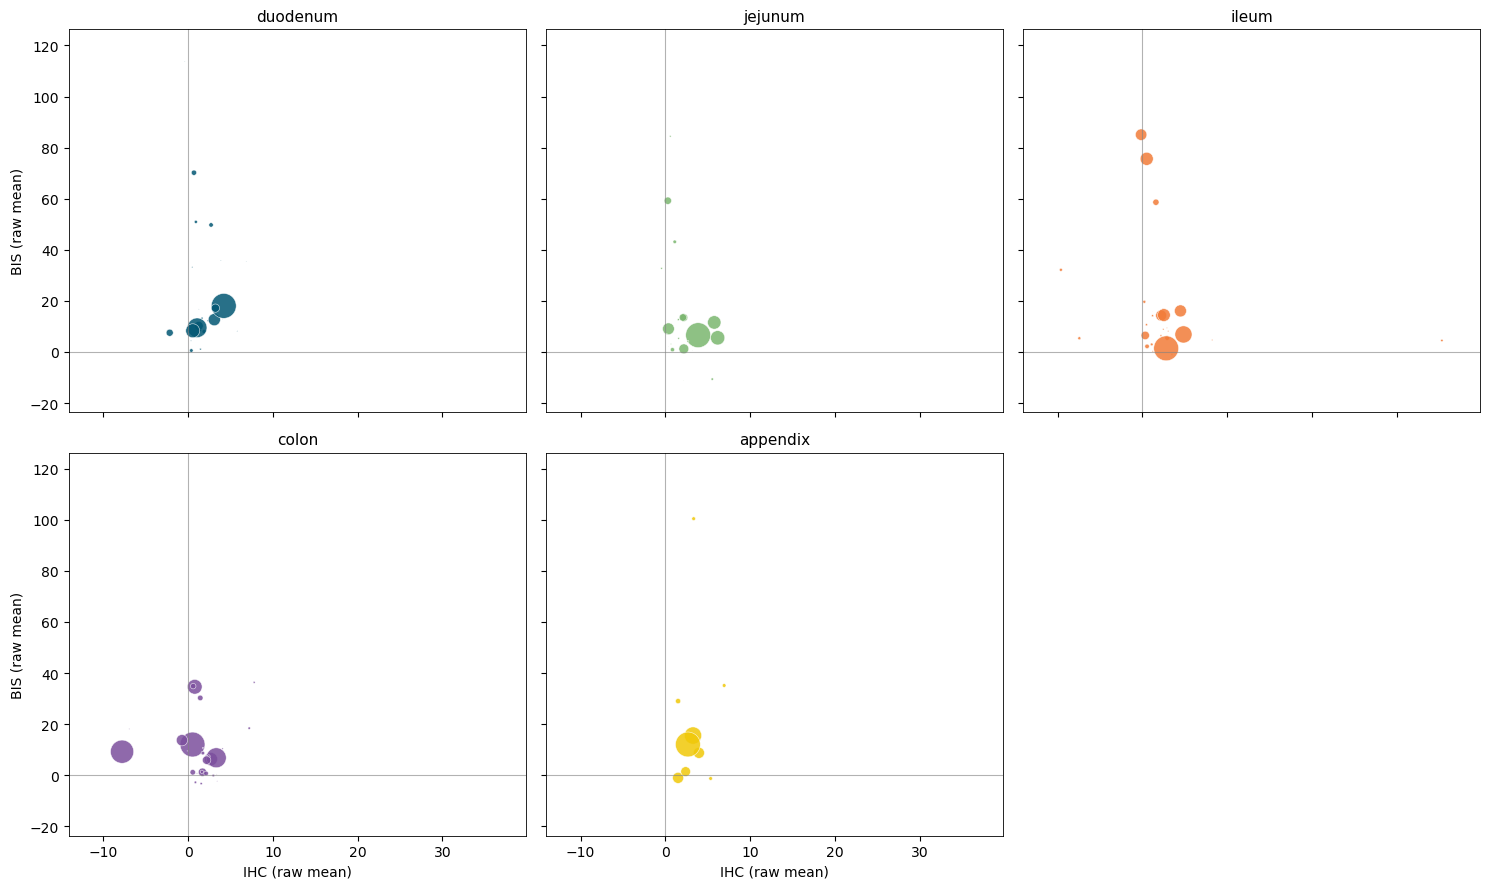

In [40]:
# Helper (if not already defined)
def style_axes_box(ax, linewidth=0.6):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(linewidth)

# Plot 1: healthy functional phase space by segment (bigger panels, grid layout)
segments_order = ["duodenum", "jejunum", "ileum", "colon", "appendix", "unknown"]
segments_present = [s for s in segments_order if s in state_summary["segment"].unique()]

subset = state_summary[state_summary["segment"].isin(segments_present)].copy()
x_all = subset["IHC_raw_mean"].values
y_all = subset["BIS_raw_mean"].values
x_pad = 0.1 * (np.nanmax(x_all) - np.nanmin(x_all) if np.isfinite(x_all).any() else 1.0)
y_pad = 0.1 * (np.nanmax(y_all) - np.nanmin(y_all) if np.isfinite(y_all).any() else 1.0)
xlim = (np.nanmin(x_all) - x_pad, np.nanmax(x_all) + x_pad)
ylim = (np.nanmin(y_all) - y_pad, np.nanmax(y_all) + y_pad)

segment_colors = {
    "duodenum": "#025773",
    "jejunum": "#7ab66f",
    "ileum": "#f27c38",
    "colon": "#7b4f9d",
    "appendix": "#f0c808",
    "unknown": "#8c8c8c",
}

n = len(segments_present)
n_cols = min(3, n)
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.0 * n_cols, 4.5 * n_rows),
    sharex=True,
    sharey=True,
)

axes = np.atleast_1d(axes).ravel()

for ax, seg in zip(axes, segments_present):
    sub = state_summary[state_summary["segment"] == seg].copy()
    x = sub["IHC_raw_mean"].values
    y = sub["BIS_raw_mean"].values
    sz = sub["n_cells"].values.astype(float)
    sz = 320.0 * (sz / np.nanmax(sz)) if np.nanmax(sz) > 0 else 40.0

    color = segment_colors.get(seg, "#025773")

    ax.scatter(
        x,
        y,
        s=sz,
        alpha=0.85,
        color=color,
        edgecolor="white",
        linewidth=0.4,
    )

    ax.set_title(seg, fontsize=11)
    ax.axhline(0, linewidth=0.8, color="gray", alpha=0.6)
    ax.axvline(0, linewidth=0.8, color="gray", alpha=0.6)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    style_axes_box(ax)

# Hide any unused axes
for ax in axes[len(segments_present):]:
    ax.axis("off")

# Label outer axes only
for i, ax in enumerate(axes[:len(segments_present)]):
    row = i // n_cols
    col = i % n_cols
    if row == n_rows - 1:
        ax.set_xlabel("IHC (raw mean)", fontsize=10)
    else:
        ax.set_xlabel("")
    if col == 0:
        ax.set_ylabel("BIS (raw mean)", fontsize=10)
    else:
        ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [23]:
# Decomposition: sample mean = composition component + expression component
# composition component uses global segment x state mean as baseline
baseline = (
    df.groupby(["segment", "cell_state"])
      .agg(BIS_base=("BIS_raw", "mean"), IHC_base=("IHC_raw", "mean"))
      .reset_index()
)

df2 = df.merge(baseline, on=["segment", "cell_state"], how="left")

# Sample-level state proportions and state means
g = df2.groupby(["segment", "sample_id", "cell_state"], dropna=False)

state_stats = g.agg(
    n=("BIS_raw", "size"),
    BIS_state_mean=("BIS_raw", "mean"),
    IHC_state_mean=("IHC_raw", "mean"),
    BIS_base=("BIS_base", "first"),
    IHC_base=("IHC_base", "first"),
).reset_index()

totals = state_stats.groupby(["segment", "sample_id"])["n"].sum().reset_index().rename(columns={"n": "n_total"})
state_stats = state_stats.merge(totals, on=["segment", "sample_id"], how="left")
state_stats["prop"] = state_stats["n"] / state_stats["n_total"]

# Components per sample
state_stats["BIS_comp_part"] = state_stats["prop"] * state_stats["BIS_base"]
state_stats["IHC_comp_part"] = state_stats["prop"] * state_stats["IHC_base"]

state_stats["BIS_expr_part"] = state_stats["prop"] * (state_stats["BIS_state_mean"] - state_stats["BIS_base"])
state_stats["IHC_expr_part"] = state_stats["prop"] * (state_stats["IHC_state_mean"] - state_stats["IHC_base"])

sample_components = (
    state_stats.groupby(["segment", "sample_id"])
      .agg(
          BIS_comp=("BIS_comp_part", "sum"),
          BIS_expr=("BIS_expr_part", "sum"),
          IHC_comp=("IHC_comp_part", "sum"),
          IHC_expr=("IHC_expr_part", "sum"),
          n_total=("n_total", "first"),
      )
      .reset_index()
)

sample_components["BIS_total"] = sample_components["BIS_comp"] + sample_components["BIS_expr"]
sample_components["IHC_total"] = sample_components["IHC_comp"] + sample_components["IHC_expr"]

sample_components.head()


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_40383/454730490.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["segment", "cell_state"])
/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_40383/454730490.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df2.groupby(["segment", "sample_id", "cell_state"], dropna=False)
/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_40383/454730490.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obs

,segment,sample_id,BIS_comp,BIS_expr,IHC_comp,IHC_expr,n_total,BIS_total,IHC_total
0,appendix,4918STDY7274839,0.0,0.0,0.0,0.0,0,0.0,0.0
1,appendix,4918STDY7333456,0.0,0.0,0.0,0.0,0,0.0,0.0
2,appendix,4918STDY7389431,0.0,0.0,0.0,0.0,0,0.0,0.0
3,appendix,4918STDY7447825,0.0,0.0,0.0,0.0,0,0.0,0.0
4,appendix,4918STDY7702680,0.0,0.0,0.0,0.0,0,0.0,0.0


In [24]:
df

,segment,tissue_layer,cell_state,BIS_raw,IHC_raw,BIS_seg_z,IHC_seg_z,sampled_site_condition,sample_collection_method,sex_ontology_term,age_range,dataset_id,donor_id,sample_id
_barcode,,,,,,,,,,,,,,
BasuGCARNA_HA01AC_AAACCCAAGTCGGGAT-1,colon,unknown,Transiently Amplifying Cells (TA),28.380673,2.743348,0.931782,0.497635,healthy,biopsy,female,50-59,BasuGCARNA,HA01,HA01-AC
BasuGCARNA_HA01AC_AAACCCAAGTGAACAT-1,colon,unknown,Lower Crypt Colonocytes,18.191967,-6.783261,0.356034,-0.916996,healthy,biopsy,female,50-59,BasuGCARNA,HA01,HA01-AC
BasuGCARNA_HA01AC_AAACCCATCTACAGGT-1,colon,unknown,Lower Crypt Colonocytes,10.232177,-0.673939,-0.093761,-0.009807,healthy,biopsy,female,50-59,BasuGCARNA,HA01,HA01-AC
BasuGCARNA_HA01AC_AAACGAATCTGGCCTT-1,colon,unknown,Lower Crypt Colonocytes,3.071917,-0.598730,-0.498376,0.001361,healthy,biopsy,female,50-59,BasuGCARNA,HA01,HA01-AC
BasuGCARNA_HA01AC_AAACGCTGTTCGTACA-1,colon,unknown,Colonocyte Progenitors,-0.057697,1.533709,-0.675226,0.318012,healthy,biopsy,female,50-59,BasuGCARNA,HA01,HA01-AC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Kong2023_N130064_N2-TTTCCTCGTAGTACCT,ileum,mucosa,Epithelial,-3.802227,0.270101,-0.562121,-0.496035,adjacent,biopsy,male,40-49,Kong2023_v2,130064,N130064_N2
Kong2023_N172428_L1-AGGATCTTCTGACCCT,ileum,mucosa,Epithelial,-7.296944,0.542251,-0.644966,-0.438318,adjacent,biopsy,female,60-69,Kong2023_v3,172428,N172428_L1
Kong2023_N168051_L2-TGGATCAGTCCCGCAA,ileum,mucosa,Epithelial,-1.056666,0.635988,-0.497035,-0.418438,adjacent,biopsy,male,50-59,Kong2023_v3,168051,N168051_L2


In [25]:
# Attach stratifiers for optional coloring later
meta_cols = ["sample_id", "donor_id", "dataset_id", "sample_collection_method", "sampled_site_condition", "sex_ontology_term", "age_range", "segment"]
sample_meta = (
    df[meta_cols].drop_duplicates(subset=["sample_id", "segment"])
)

sample_components = sample_components.merge(sample_meta, on=["sample_id", "segment"], how="left")
sample_components.head()


,segment,sample_id,BIS_comp,BIS_expr,IHC_comp,IHC_expr,n_total,BIS_total,IHC_total,donor_id,dataset_id,sample_collection_method,sampled_site_condition,sex_ontology_term,age_range
0,appendix,4918STDY7274839,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,appendix,4918STDY7333456,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,appendix,4918STDY7389431,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,appendix,4918STDY7447825,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,appendix,4918STDY7702680,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


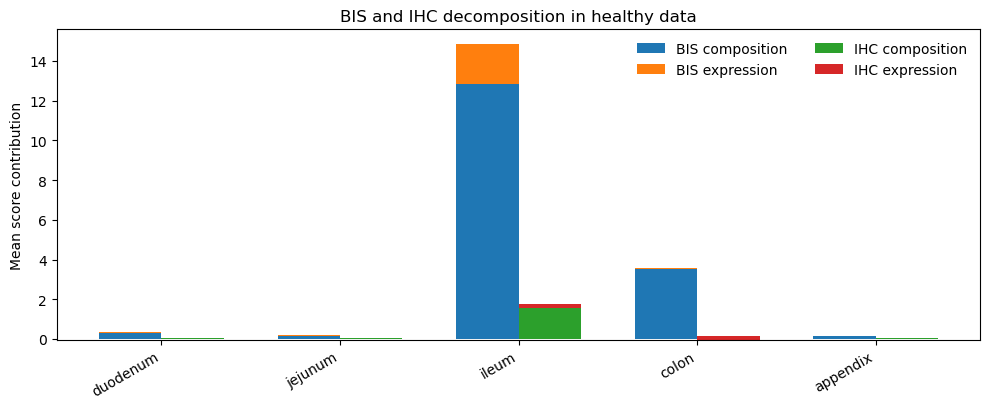

In [26]:
# Plot 2: expression vs composition breakdown by segment
seg_means = (
    sample_components.groupby("segment")
      .agg(
          BIS_comp=("BIS_comp", "mean"),
          BIS_expr=("BIS_expr", "mean"),
          IHC_comp=("IHC_comp", "mean"),
          IHC_expr=("IHC_expr", "mean"),
          n_samples=("sample_id", pd.Series.nunique),
      )
      .reset_index()
)

segments_present = [s for s in segments_order if s in seg_means["segment"].unique()]
seg_means = seg_means.set_index("segment").loc[segments_present].reset_index()

x = np.arange(len(seg_means))
w = 0.35

fig, ax = plt.subplots(figsize=(1.6 * len(seg_means) + 2, 4.2))

ax.bar(x - w/2, seg_means["BIS_comp"], width=w, label="BIS composition")
ax.bar(x - w/2, seg_means["BIS_expr"], width=w, bottom=seg_means["BIS_comp"], label="BIS expression")

ax.bar(x + w/2, seg_means["IHC_comp"], width=w, label="IHC composition")
ax.bar(x + w/2, seg_means["IHC_expr"], width=w, bottom=seg_means["IHC_comp"], label="IHC expression")

ax.set_xticks(x)
ax.set_xticklabels(seg_means["segment"], rotation=30, ha="right")
ax.set_ylabel("Mean score contribution")
ax.set_title("BIS and IHC decomposition in healthy data")
ax.legend(ncol=2, frameon=False)

plt.tight_layout()
plt.show()


In [27]:
# Optional: same decomposition but stratified within segment by sampled_site_condition
grp = (
    sample_components.groupby(["segment", "sampled_site_condition"])
      .agg(
          BIS_total=("BIS_total", "mean"),
          IHC_total=("IHC_total", "mean"),
          n_samples=("sample_id", pd.Series.nunique),
      )
      .reset_index()
)
grp.sort_values(["segment", "sampled_site_condition"]).head(20)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_40383/3332493707.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_components.groupby(["segment", "sampled_site_condition"])


,segment,sampled_site_condition,BIS_total,IHC_total,n_samples
0,appendix,adjacent,NaN,NaN,NaN
1,appendix,healthy,13.858055,2.658587,4.0
2,colon,adjacent,14.035735,-0.484533,11.0
3,colon,healthy,10.824207,0.491534,108.0
4,duodenum,adjacent,NaN,NaN,NaN
5,duodenum,healthy,12.274506,2.736037,9.0
6,ileum,adjacent,20.843737,2.561342,97.0
7,ileum,healthy,27.234189,3.219660,128.0
8,jejunum,adjacent,NaN,NaN,NaN
9,jejunum,healthy,8.669331,3.743245,7.0


In [28]:
adata_epi.obs['tissue'].value_counts()

tissue
ileum                 178040
ascending colon        53614
duodenum                6814
transverse colon        5881
sigmoid colon           5550
colon                   5448
rectum                  5202
jejunum                 3925
descending colon        2102
small intestine         1907
caecum                  1164
vermiform appendix        98
ascending_colon           34
sigmoid_colon              1
Name: count, dtype: int64

In [29]:
adata

AnnData object with n_obs × n_vars = 269780 × 35574
    obs: 'sample_id', 'author_cell_type', 'doublet_score', 'annotation_cluster', 'predicted_doublet', 'leiden_lineage_l1', 'leiden_lineage_l2', 'qc_lineage', 'n_counts', 'n_genes', 'donor_id', 'dataset_id', 'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'disease_ontology_term', 'disease_ontology_term_id', 'sample_preservation_method', 'suspension_type', 'is_primary_data', 'age_range', 'development_stage_ontology_term_id', 'radial_tissue_term', 'dissociation_protocol', 'cell_enrichment', 'sample_collection_year', 'library_id', 'library_id_repository', 'library_preparation_batch', 'library_sequencing_run', 'sample_collection_site', 'sample_collection_relative_time_point', 'cell_number_loaded', 'cell_viability_percentage', 'institute', 'author_batch_notes', 'consortia', 'study_pi', 'contact_email', 'batch_condition', 'default_emb